# The problem with small datasets

In this notebook, we will use the features that we estimated to train a classification model. We will limit to a Logistic Regression model as these models are easy to interpret.

In [1]:
#Lets load the data and visualize it according to its class
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#Load the data and take a look at it
data = pd.read_csv('data/gait_measures_PD_controls_ALL.csv')
data.dropna(inplace=True)
data

,ID,class,avg_speed,avg_stride_time_left,avg_stride_time_right,avg_stance_time_left,avg_stance_time_right,avg_swing_time_left,avg_swing_time_right,avg_step_time,avg_step_length,cv_stride_time_left,cv_stride_time_right,cv_stance_time_left,cv_stance_time_right,cv_swing_time_left,cv_swing_time_right,cv_step_time,cadence
0,GaCo01,0,1.075,1.262122,1.150599,0.812891,0.732958,0.449232,0.417641,0.610381,0.656160,0.156720,0.241584,0.257093,0.281841,0.097879,0.279530,0.116472,98.299251
1,GaCo02,0,1.040,1.156327,1.114366,0.762472,0.723282,0.393855,0.391083,0.546211,0.568059,0.258712,0.098756,0.393364,0.170477,0.053354,0.144025,0.046618,109.847745
2,GaCo02,0,1.040,1.062846,1.035100,0.690572,0.671936,0.372274,0.363164,0.519350,0.540124,0.057104,0.135287,0.098826,0.198504,0.048331,0.162915,0.101274,115.529027
3,GaCo03,0,1.051,1.277145,1.236099,0.886954,0.808403,0.390190,0.427696,0.636057,0.668496,0.169972,0.141101,0.242485,0.189992,0.131595,0.174924,0.123305,94.331192
4,GaCo03,0,1.051,1.092832,1.056652,0.723311,0.681194,0.369521,0.375458,0.554777,0.583071,0.142381,0.185621,0.179209,0.262731,0.173101,0.240926,0.194714,108.151510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,SiPt36,1,0.970,1.038363,1.059749,0.693432,0.727473,0.344930,0.332276,0.529444,0.513561,0.164386,0.079557,0.169066,0.103554,0.193477,0.086716,0.075903,113.326440
302,SiPt37,1,1.010,1.238976,1.135392,0.838065,0.756927,0.400911,0.378464,0.620886,0.627094,0.262026,0.260660,0.388940,0.281718,0.167968,0.282575,0.082096,96.636165
303,SiPt38,1,1.070,1.163122,1.164384,0.770624,0.774992,0.392498,0.389392,0.572583,0.612663,0.033968,0.044612,0.042563,0.041039,0.051899,0.074005,0.057316,104.788388
304,SiPt39,1,0.880,1.012954,1.073943,0.696085,0.758342,0.316869,0.315601,0.546236,0.480687,0.184435,0.034470,0.255025,0.033829,0.252009,0.086741,0.152573,109.842714


In [10]:
from sklearn.model_selection import LeaveOneOut
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Prepare the data for modeling by separating features and target variable
X = data.drop(columns=['ID', 'class'])
y = data['class']
# and split the data intor training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=18, stratify=y)


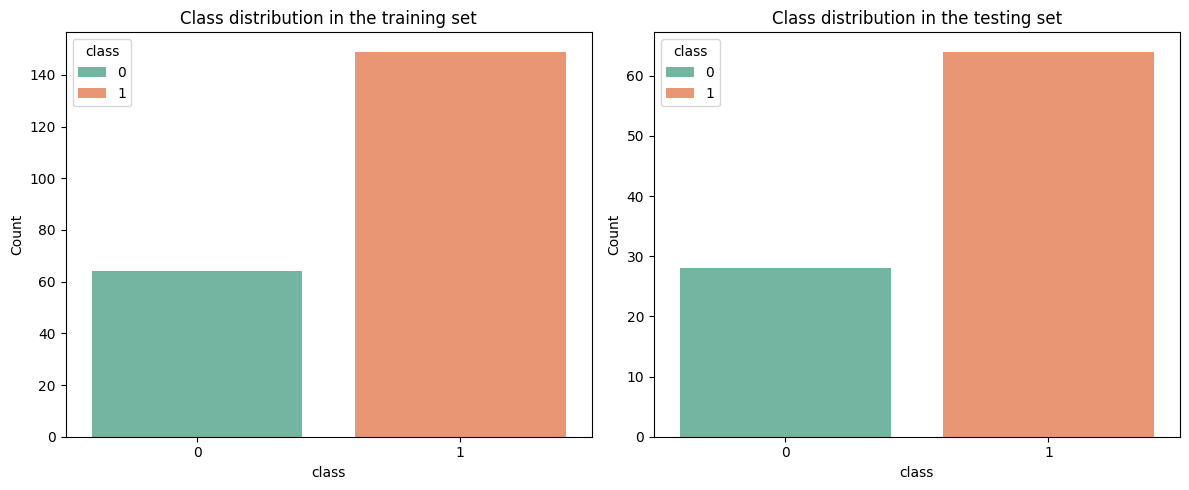

In [3]:
#lets count the number of samples in each class in the training and test sets
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=y_train, hue=y_train, palette="Set2", ax=ax[0])
ax[0].set_title("Class distribution in the training set")
ax[0].set_ylabel("Count")
sns.countplot(x=y_test, hue=y_test, palette="Set2", ax=ax[1])
ax[1].set_title("Class distribution in the testing set")
ax[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

Note that we now have many samples in out test set!

              precision    recall  f1-score   support

           0       0.73      0.86      0.79        28
           1       0.93      0.86      0.89        64

    accuracy                           0.86        92
   macro avg       0.83      0.86      0.84        92
weighted avg       0.87      0.86      0.86        92

[[24  4]
 [ 9 55]]


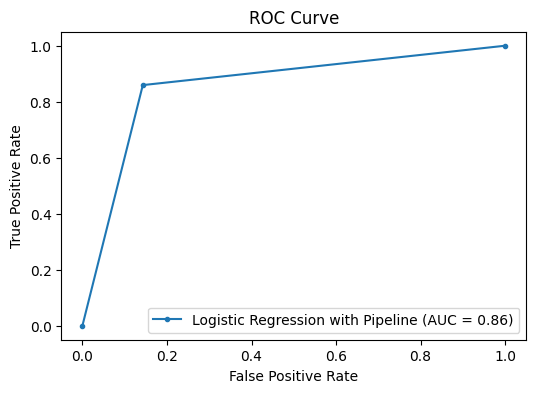

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

#lets train a logistic regression model with a pipeline that includes standardization of the features

#define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(class_weight='balanced', random_state=42))
])
#fit the pipeline using the training data
pipeline.fit(X_train, y_train)

#evaluate the pipeline using the testing data
y_pred_pipeline = pipeline.predict(X_test)

#print the classification report, confusion matrix, and ROC curve for the pipeline
print(classification_report(y_test, y_pred_pipeline))

print(confusion_matrix(y_test, y_pred_pipeline))

fpr, tpr, _ = roc_curve(y_test, y_pred_pipeline)
auc_score = roc_auc_score(y_test, y_pred_pipeline)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, marker='.', label='Logistic Regression with Pipeline (AUC = {:.2f})'.format(auc_score))
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


This is a really starting point, the majority of healthy controls can be properly recognized (24 out of 28 in the test set) and most all patients can be recognized (55 out of 64). 

Lets try to improve the model by looking at what features are most important. For this, we need to **Scale** the feature column so that all the columns have the same mean and standard deviation and the coefficients of the model can be compared directly. 

              precision    recall  f1-score   support

           0       0.73      0.86      0.79        28
           1       0.93      0.86      0.89        64

    accuracy                           0.86        92
   macro avg       0.83      0.86      0.84        92
weighted avg       0.87      0.86      0.86        92

[[24  4]
 [ 9 55]]


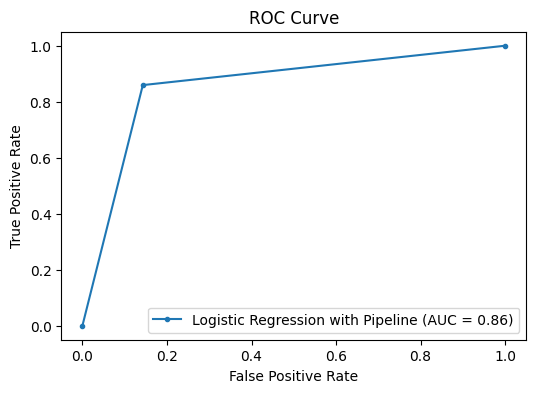

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

#lets train a logistic regression model with a pipeline that includes standardization of the features

#define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42))
])
#fit the pipeline using the training data
pipeline.fit(X_train, y_train)

#evaluate the pipeline using the testing data
y_pred_pipeline = pipeline.predict(X_test)

#print the classification report, confusion matrix, and ROC curve for the pipeline
print(classification_report(y_test, y_pred_pipeline))

print(confusion_matrix(y_test, y_pred_pipeline))

fpr, tpr, _ = roc_curve(y_test, y_pred_pipeline)
auc_score = roc_auc_score(y_test, y_pred_pipeline)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, marker='.', label='Logistic Regression with Pipeline (AUC = {:.2f})'.format(auc_score))
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


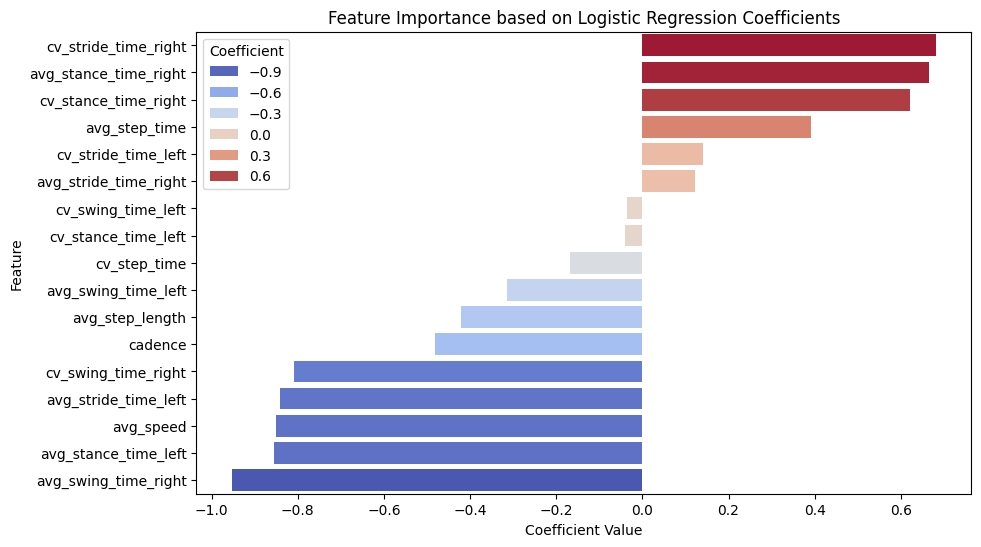

In [6]:
#now lets visualize the coefficients of the logistic regression model to see which features are more important for the classification task
coefficients = pipeline.named_steps['model'].coef_[0]
feature_names = X.columns
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, hue='Coefficient', palette='coolwarm')
plt.title('Feature Importance based on Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()  

It is very clear that some features are not doing much (their standardized weights are almost zero). So we can use a feature selection approach to eliminate features that do not contribute for classification. 

Best parameters found:  {'SelectKBest__k': 10, 'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best AUC score:  0.8753109342764516
              precision    recall  f1-score   support

           0       0.71      0.54      0.61        28
           1       0.82      0.91      0.86        64

    accuracy                           0.79        92
   macro avg       0.77      0.72      0.74        92
weighted avg       0.79      0.79      0.78        92

[[15 13]
 [ 6 58]]


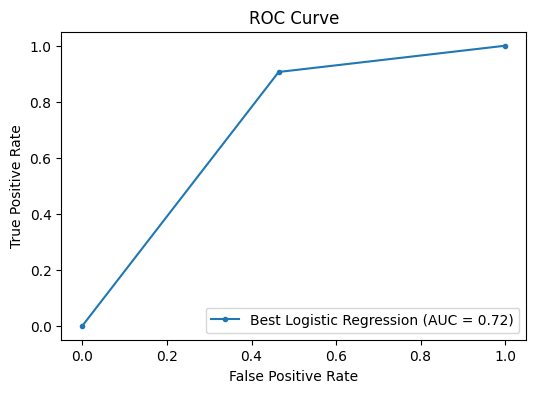

In [13]:

# At this point, we should use our traning data to define which features and model paramertes give the best performance, 
# and then use the test data to evaluate the performance of the model with the selected features and parameters.

from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif
from sklearn.model_selection import GridSearchCV 

#define a pipeline that includes standardization of the features, feature selection using SelectKBest, and a logistic regression model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('SelectKBest', SelectKBest(score_func= mutual_info_classif)),
    ('model', LogisticRegression( max_iter=5000, random_state=42))
])

params_grid_LogisticRegression = [   
    {
        #parameters for the logistic regression model
        'model__penalty': ['l1', 'l2',],
        'model__C': [0.01, 0.1, 1, 10, 100,1000],
        'model__class_weight': ['balanced', None],
        'model__solver': ['liblinear'],
        #parameters for the feature selection step
        'SelectKBest__k': [5,10,15, 'all'],
    },
]

#define the grid search with the pipeline and the parameters grid, and   
grid_search = GridSearchCV(estimator=pipeline, param_grid=params_grid_LogisticRegression, cv=5, scoring='roc_auc')
#fit it using the training data and 
grid_search.fit(X_train, y_train)
#print the best parameters and the best AUC score obtained during the grid search
print("Best parameters found: ", grid_search.best_params_)
print("Best AUC score: ", grid_search.best_score_)


#evaluate the best model obtained from the grid search using the testing data
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

#print the classification report, confusion matrix, and ROC curve for the best model
print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))
fpr, tpr, _ = roc_curve(y_test, y_pred_best)
auc_score = roc_auc_score(y_test, y_pred_best)
plt.figure(figsize=(6, 4))

plt.plot(fpr, tpr, marker='.', label='Best Logistic Regression (AUC = {:.2f})'.format(auc_score))
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


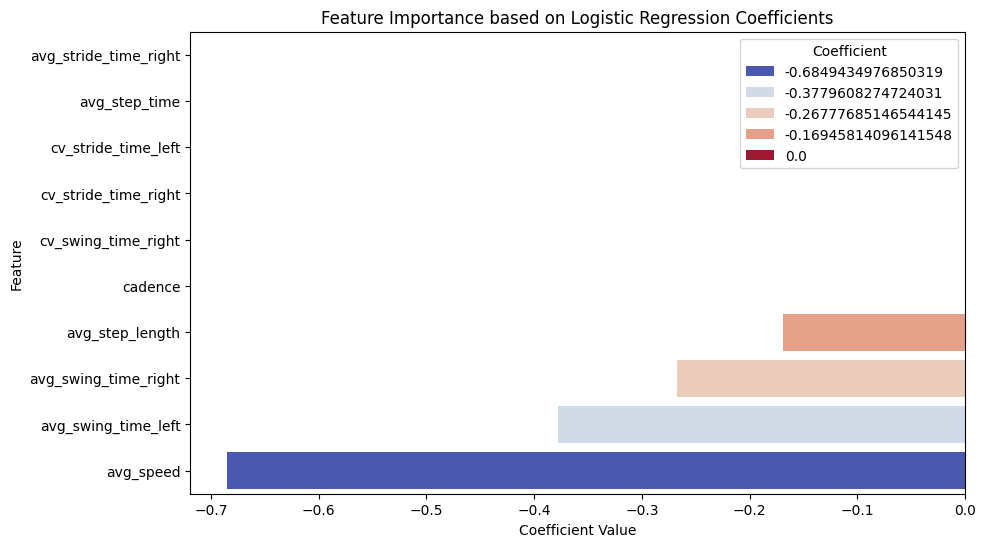

In [14]:
coefficients = best_model.named_steps['model'].coef_[0]
feature_names = X.columns[best_model.named_steps['SelectKBest'].get_support()]
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, hue='Coefficient', palette='coolwarm')
plt.title('Feature Importance based on Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()  

We obtained a simpler model that is as more accurate! 

Now, if you change the `random_state` here

```Python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
````

you should see similar results. 